# FEMTO bearing RUL — Initial EDA

Condition/bearing distributions, degradation trend visualizations, and the
rationale behind the RMSE + PHM12 scoring metric choice. Reads
`data/processed/features.parquet` (produced by `scripts/extract_features.py`).
See `docs/data_notes.md` for the labeling scheme and feature schema this
builds on.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

from femto_rul.config import DATA_DIR

df = pd.read_parquet(DATA_DIR / "processed" / "features.parquet")

# Categorical palette — validated set (docs/data_notes.md), fixed hue-per-condition order.
COND_COLORS = {1: "#2a78d6", 2: "#eb6834", 3: "#1baf7a"}  # blue / orange / aqua
SEQUENTIAL_BLUE = "#2a78d6"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": INK_MUTED,
    "axes.labelcolor": INK_SECONDARY,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "lines.linewidth": 2,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "figure.dpi": 110,
})

df.shape

(38848, 30)

## Dataset overview

Bearing counts and full run lengths per operating condition. `Test_set` is
excluded from lifespan figures since it's deliberately truncated — its
bearings' file counts don't reflect true lifespan (see `docs/data_notes.md`).

In [ ]:
df.head(10)

,split,condition,bearing,elapsed_time_seconds,file_index,rms_horiz,kurtosis_horiz,skewness_horiz,crest_factor_horiz,fft_band_0_horiz,...,crest_factor_vert,fft_band_0_vert,fft_band_1_vert,fft_band_2_vert,fft_band_3_vert,fft_band_4_vert,fft_band_5_vert,fft_band_6_vert,fft_band_7_vert,rul_seconds
38838,Test_set,3,Bearing3_3,3420,343,0.461724,0.218990,-0.065423,3.525919,23.283158,...,5.057115,4.149270,8.971810,27.277538,15.468973,27.077525,254.140020,462.799740,52.703836,910
38839,Test_set,3,Bearing3_3,3430,344,0.475699,0.306513,-0.048179,3.828054,16.070748,...,4.994183,8.346538,8.412664,25.193646,16.786858,26.399219,213.892748,481.393773,68.092950,900
38840,Test_set,3,Bearing3_3,3440,345,0.497842,0.847324,-0.014358,3.999258,15.846186,...,4.552193,4.621868,7.730955,26.263935,17.141292,31.075348,286.032058,610.385523,67.043226,890
38841,Test_set,3,Bearing3_3,3450,346,0.465231,0.440380,-0.028225,3.813160,19.359579,...,5.459341,4.445844,13.014847,27.713827,17.592292,25.004694,199.052041,525.705803,60.401058,880
38842,Test_set,3,Bearing3_3,3460,347,0.478239,0.032667,-0.039977,3.824451,21.404724,...,4.200463,6.905430,7.648283,27.978106,16.169107,29.620452,252.676602,567.018385,53.879149,870
38843,Test_set,3,Bearing3_3,3470,348,0.475071,0.215834,0.013287,3.658401,18.612062,...,3.970934,3.534471,7.645324,24.510074,15.249741,28.825649,225.422717,421.239442,51.426893,860
38844,Test_set,3,Bearing3_3,3480,349,0.501383,0.729044,-0.040408,4.288137,35.940011,...,3.887128,4.456037,10.405954,21.149975,20.037673,26.636950,273.138679,624.644359,59.646636,850
38845,Test_set,3,Bearing3_3,3490,350,0.515259,0.151305,-0.079296,3.609838,36.311198,...,5.460303,3.953902,9.219325,29.764446,16.074806,27.065710,254.846059,512.855552,66.625717,840
38846,Test_set,3,Bearing3_3,3500,351,0.511783,0.169648,-0.037828,3.864921,23.347856,...,3.833374,5.101018,10.570528,29.204312,16.976309,30.567479,230.701399,459.605201,68.760022,830
38847,Test_set,3,Bearing3_3,3510,352,0.508292,0.356503,-0.006550,3.773419,14.218064,...,4.470001,3.652510,11.201895,29.328291,17.227203,27.941470,272.362637,600.759821,64.556215,820


In [2]:
bearing_summary = (
    df.groupby(["split", "condition", "bearing"])
      .agg(n_snapshots=("file_index", "size"),
           run_length_hours=("elapsed_time_seconds", lambda s: s.max() / 3600))
      .reset_index()
      .sort_values(["split", "condition", "bearing"])
)
bearing_summary.groupby(["split", "condition"]).agg(
    n_bearings=("bearing", "nunique"),
    total_rows=("n_snapshots", "sum"),
)

n_bearings  total_rows
split          condition                        
Test_set       1                   5        9047
               2                   5        4560
               3                   1         352
Training_set   1                   2        3674
               2                   2        1708
               3                   2        2152
Validation_Set 1                   5       10973
               2                   5        5948
               3                   1         434

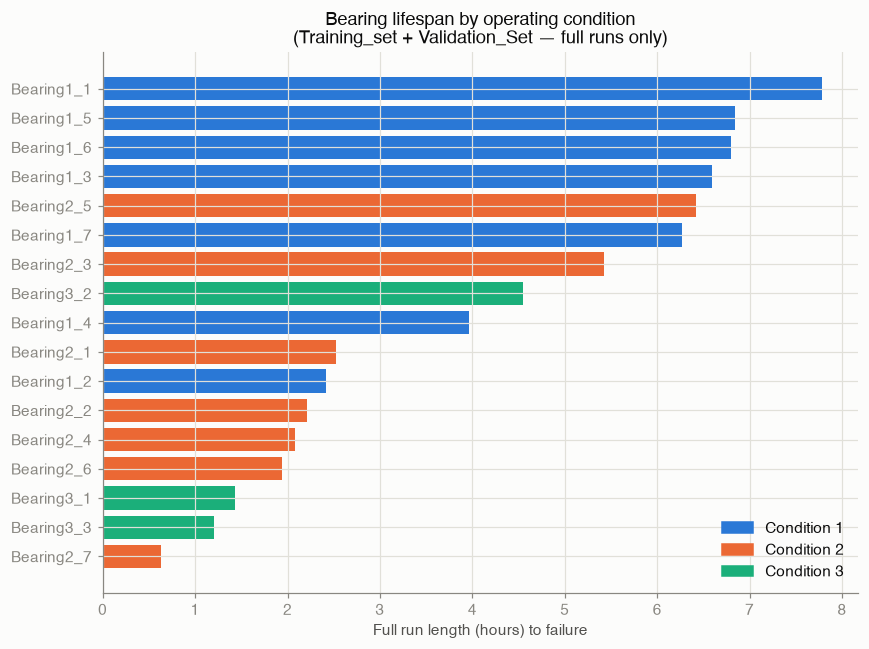

In [3]:
full_run = bearing_summary[bearing_summary["split"].isin(["Training_set", "Validation_Set"])].copy()
assert full_run["bearing"].is_unique  # Training_set (_1/_2) and Validation_Set (_3.._7) bearing names don't collide
full_run = full_run.sort_values("run_length_hours")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(full_run["bearing"], full_run["run_length_hours"], color=full_run["condition"].map(COND_COLORS))
ax.set_xlabel("Full run length (hours) to failure")
ax.set_title("Bearing lifespan by operating condition\n(Training_set + Validation_Set — full runs only)")
ax.legend(handles=[Patch(color=COND_COLORS[c], label=f"Condition {c}") for c in sorted(COND_COLORS)],
          frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

## Degradation trend visualizations

One representative bearing per condition (`Bearing1_1`, `Bearing2_1`,
`Bearing3_2` — the longer-lived training bearing in each condition, for a
clearer trend). Same three colors as above, held constant across panels.

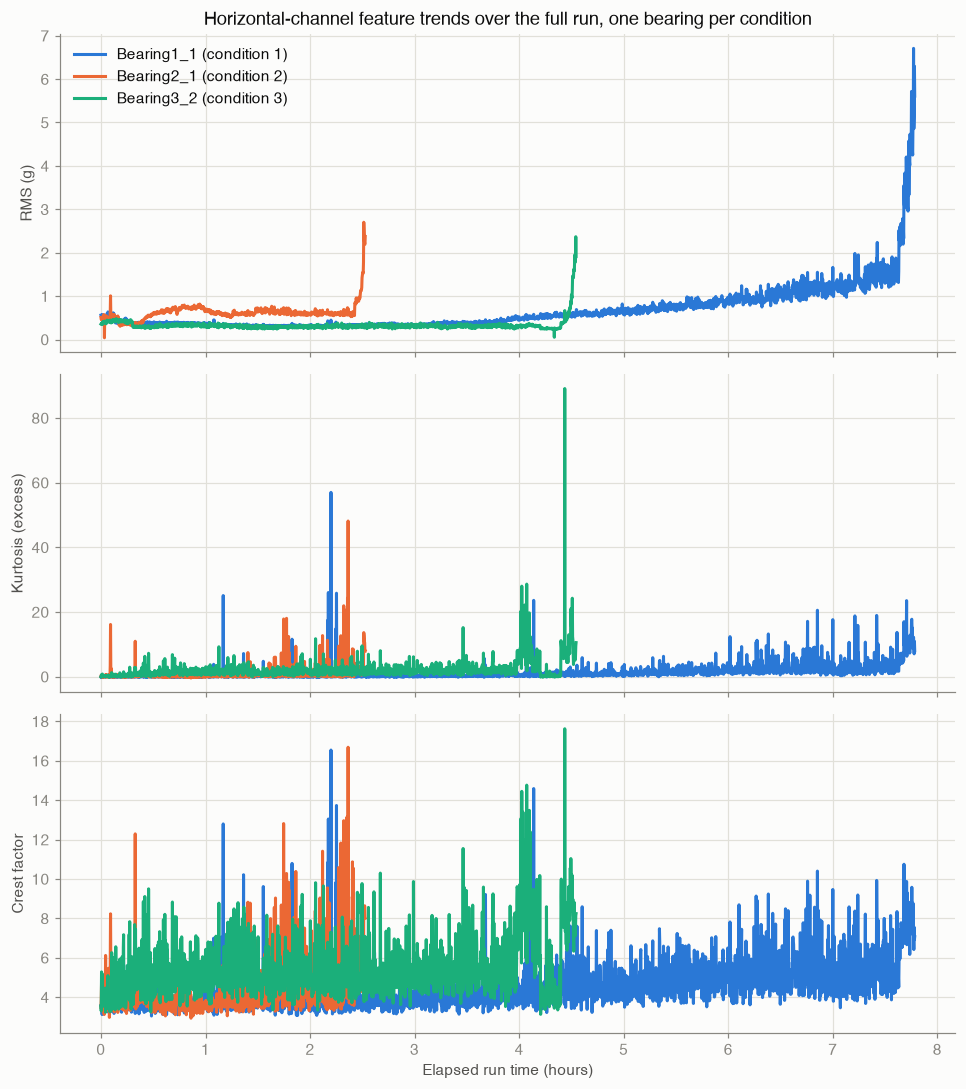

In [4]:
representative = {1: "Bearing1_1", 2: "Bearing2_1", 3: "Bearing3_2"}
feature_panels = [
    ("rms_horiz", "RMS (g)"),
    ("kurtosis_horiz", "Kurtosis (excess)"),
    ("crest_factor_horiz", "Crest factor"),
]

fig, axes = plt.subplots(len(feature_panels), 1, figsize=(9, 10), sharex=True)
for ax, (col, label) in zip(axes, feature_panels):
    for cond, bearing in representative.items():
        sub = df[(df["bearing"] == bearing) & (df["split"] == "Training_set")].sort_values("elapsed_time_seconds")
        ax.plot(sub["elapsed_time_seconds"] / 3600, sub[col], color=COND_COLORS[cond],
                label=f"{bearing} (condition {cond})")
    ax.set_ylabel(label)

axes[-1].set_xlabel("Elapsed run time (hours)")
axes[0].legend(frameon=False, loc="upper left")
axes[0].set_title("Horizontal-channel feature trends over the full run, one bearing per condition")
plt.tight_layout()
plt.show()

**What this shows**: RMS is the most reliable single indicator here — all
three bearings stay flat and low for most of their run, then rise sharply in
a final stretch right before failure, regardless of operating condition.
Kurtosis and crest factor are much noisier: large impulsive-looking spikes
show up throughout each run, not only near failure — e.g. `Bearing1_1` has a
spike to kurtosis ≈ 57 only ~25% into its ~7.8h life, with no obvious
connection to its eventual failure hours later. That makes them less
reliable as standalone per-snapshot predictors than RMS; they likely need to
be aggregated over a rolling window (rather than used raw per-snapshot) to
turn into a clean degradation signal, which is worth trying once we get to
modeling.

## Bearing lifespan spread by condition

Only 17 full-run bearings total across 3 conditions — too few per group for a
histogram to read cleanly, so this uses a dot plot (one point per bearing)
instead of binning into a sparse histogram.

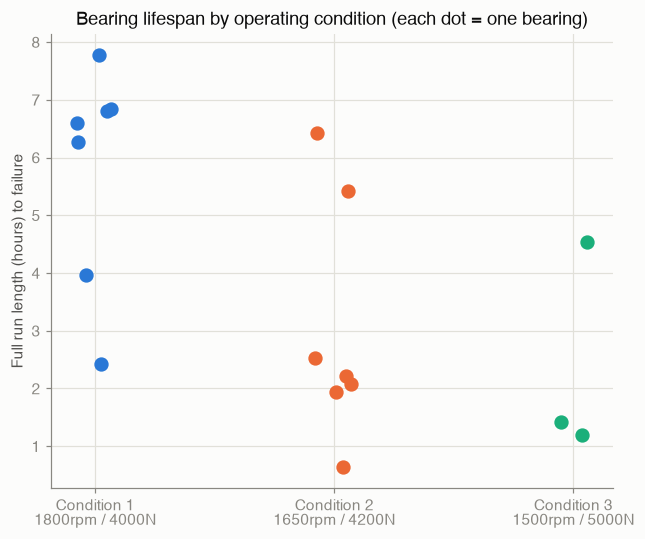

In [5]:
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(6, 5))
for cond in sorted(COND_COLORS):
    sub = full_run[full_run["condition"] == cond]
    x = cond + rng.uniform(-0.08, 0.08, size=len(sub))
    ax.scatter(x, sub["run_length_hours"], color=COND_COLORS[cond], s=70, zorder=3)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Condition 1\n1800rpm / 4000N", "Condition 2\n1650rpm / 4200N", "Condition 3\n1500rpm / 5000N"])
ax.set_ylabel("Full run length (hours) to failure")
ax.set_title("Bearing lifespan by operating condition (each dot = one bearing)")
plt.tight_layout()
plt.show()

**What this shows**: condition 1 (highest speed, lowest load) bearings
cluster toward longer lifespans (mostly 4–8h, one outlier at 2.4h), while
condition 2 and 3 (higher load) skew shorter and more spread out — condition
2 ranges from 0.6h to 6.4h, condition 3's 3 bearings all sit under 5h. This
is directionally consistent with harsher load/lower speed shortening bearing
life, but condition 3 only has 3 full-run bearings total, so treat that
comparison as suggestive, not conclusive.

## Metric choice: RMSE + PHM12 asymmetric scoring

Plain RMSE penalizes an early prediction and a late prediction of the same
magnitude identically. That's a poor match for this problem: predicting
failure *too late* means missing the maintenance window entirely (safety
risk, unplanned downtime), while predicting *too early* just costs some
unused remaining service life (conservative, but safe). The PHM12 challenge's
scoring function captures that asymmetry directly.

**Caveat**: the exact formula below (an asymmetric exponential, steeper on
the late side) is the version commonly cited in the RUL literature for this
challenge. We don't have the official challenge documentation bundled with
our downloaded dataset, so the denominator constants (5 / 20) should be
verified against the original PHM 2012 Data Challenge write-up before this
is used for an actual leaderboard-style score — what matters for now is the
*shape* of the asymmetry, which is what justifies using it alongside RMSE.

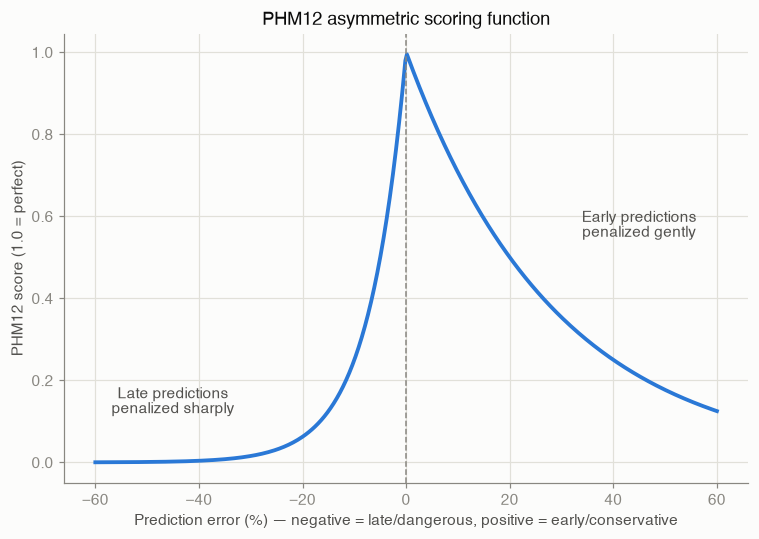

(array(0.0625), array(0.5))

In [6]:
def phm12_score(error_pct):
    """error_pct = 100 * (true_rul - predicted_rul) / true_rul.
    Positive: predicted RUL fell short of the true value (early/conservative).
    Negative: predicted RUL overshot the true value (late/dangerous).
    """
    error_pct = np.asarray(error_pct, dtype=float)
    return np.where(
        error_pct <= 0,
        np.exp(np.log(0.5) * (-error_pct / 5)),   # late predictions: steep penalty
        np.exp(np.log(0.5) * (error_pct / 20)),   # early predictions: gentle penalty
    )

errors = np.linspace(-60, 60, 400)
scores = phm12_score(errors)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(errors, scores, color=SEQUENTIAL_BLUE, linewidth=2.5)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("Prediction error (%) — negative = late/dangerous, positive = early/conservative")
ax.set_ylabel("PHM12 score (1.0 = perfect)")
ax.set_title("PHM12 asymmetric scoring function")
ax.text(-45, 0.12, "Late predictions\npenalized sharply", color=INK_SECONDARY, ha="center")
ax.text(45, 0.55, "Early predictions\npenalized gently", color=INK_SECONDARY, ha="center")
plt.tight_layout()
plt.show()

# at the same 20% error magnitude, how much harsher is a late prediction than an early one?
phm12_score(-20), phm12_score(20)

## Summary

- 3 operating conditions, bearing lifespans vary considerably even within
  the same condition — a raw-seconds RUL label will have a very different
  scale bearing to bearing (see `docs/data_notes.md` for how we're handling
  that).
- RMSE alone doesn't reflect the real cost asymmetry of this problem; the
  PHM12 score does, which is why the proposal commits to both.
- Next: baseline model (Week 1) using this feature table directly.